In [1]:
import numpy as np
import sys
from pathlib import Path
import copy
from time import time

Base_Dir = './' # assuming we are in zeldovich-smearing/emulation/, else modify this
Code_Dir = Base_Dir + '../code/'
sys.path.append(Code_Dir)

from emulation import AgnosticEmulator

In [2]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib as mpl
import matplotlib.colors as pltcol

mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['legend.fontsize'] = 16 # 14
mpl.rcParams['legend.labelspacing'] = 0.25

FS = 18
FS2 = 15
FS3 = 13
FSL = 22

mpl.rcParams['xtick.major.size'] = 6
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['ytick.major.size'] = 6
mpl.rcParams['ytick.minor.size'] = 3
print('mpl setup done')
#mpl.rcParams.keys()

mpl setup done


***
# Agnostic $\leftrightarrow$ Cosmological Emulation
### Load and use forward and inverse emulators for model-agnostic BAO inference
***

## Setup

In [28]:
Cosmo = 'lcdm'  # one of ['lcdm','wcdm','nucdm','w0wacdm']
Flat = True     # whether or not to vary spatial curvature
Z_Eval = 0.8

Loc_Stem = 'emulators/'
Model_Name = 'shallow' # one of existing models, e.g., 'shallow','telescopic'
Perc = 0.1 # should match what was used when generating data samples

# Set the variable below to True to perform the 'stringent' test of arXiv:2410.21374 
# which assesses the performance of the BiSequential basis in describing the chosen model.
# This can be done regardless of the existence of any emulator, 
# but needs test data to have been generated with 'save_xi':True.
Perform_Stringent_Test = True

CMap = plt.cm.plasma # useful for plotting

# minimal setup dict needed to load AgnosticEmulator instance
setup = {'out_stem':Loc_Stem+'z{0:.2f}/'.format(Z_Eval),
         'cosmo':Cosmo,'flat':Flat,'z_eval':Z_Eval,'perc':Perc}

In [26]:
agem = AgnosticEmulator(setup=setup)

Agnostic emulator for BAO inference...
... extracting basis functions as NN
... done
... evaluating 9 basis functions
... done
... setting up fiducial cosmology and sampling ranges
... setting up parameter variations for family: lcdm (flat)
... fiducial params:
... ... Om: 3.1530e-01
... ... h: 6.7370e-01
... ... As: 2.1010e-09
... ... ns: 9.6490e-01
... ... Ob: 4.9287e-02
... setup complete
0 min 7.54 seconds



## Load 

### Test data

In [23]:
if Perform_Stringent_Test:
    agnostic,cosmological,xilin = agem.gen_sample(sample_setup={'sample_stem':'test','save_xi':True})
else:
    agnostic,cosmological = agem.gen_sample(sample_setup={'sample_stem':'test'})

n_samp = agnostic.shape[1]

Generating/reading sample from :emulators/z0.80/lcdm_flat/samples/test
... folder exists, attempting to read
... read 200 samples
0 min 0.00 seconds



#### Optional stringent test for basis set

[....................] 100% done
16,50,84 pc residual: -1.733e-02,-6.941e-05,1.228e-02
width: 1.481e-02
Saving to file: emulators/z0.80/lcdm_flat/plots/stringent_test.pdf
0 min 0.46 seconds



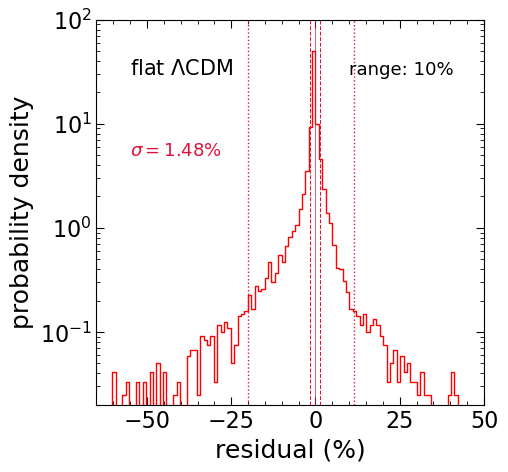

In [56]:
if Perform_Stringent_Test:
    Save_Fig_Stringent = True
    
    start_time = time()
    xilin_predict = np.zeros_like(xilin)
    for n in range(n_samp):
        xilin_predict[n] = np.dot(agem.basis_func.T,agnostic[:agem.n_basis,n])
        agem.status_bar(n,n_samp)

    residual_matrix = xilin_predict/(xilin + 1e-15) - 1
    residual = residual_matrix.flatten()

    print('16,50,84 pc residual: {0:.3e},{1:.3e},{2:.3e}'.format(np.percentile(residual,16),np.median(residual),
                                                                 np.percentile(residual,84)))
    width = 0.5*(np.percentile(residual,84)-np.percentile(residual,16))
    print('width: {0:.3e}'.format(width))

    # plt.figure(figsize=(4,4))
    # plt.ylim(-0.3,0.3)
    # cols = iter(CMap(np.linspace(0,1,n_samp)))
    # for n in range(n_samp):
    #     col = next(cols)
    #     plt.plot(agem.rvals,residual_matrix[n],'-',color=col,lw=0.25)
    # plt.minorticks_on()
    # plt.show()

    bins=np.linspace(-1,1,200)
    bin_mid = 0.5*(bins[1:]+bins[:-1])
    
    hist,bins = np.histogram(residual,bins=bins,density=False)
    hist = hist/residual.size/(bins[1]-bins[0])
    
    FSize = 5
    plt.figure(figsize=(FSize,FSize))
    plt.yscale('log')
    plt.xlim(-65,50)
    plt.ylim(2e-2,1e2)
    plt.xlabel('residual (%)')
    plt.ylabel('probability density')
    plt.plot(bin_mid*100,hist,'r-',drawstyle='steps',lw=1)
    plt.text(-55,5,'$\\sigma = {0:.2f}\%$'.format(width*100),fontsize=FS3,c='crimson')
    plt.text(10,30,'range: {0:.0f}%'.format(agem.perc*100),fontsize=FS3)
    plt.axvline(np.median(residual)*100,ls='-',lw=0.5,c='crimson')
    plt.axvline(np.percentile(residual,16)*100,ls='--',lw=0.75,c='crimson')
    plt.axvline(np.percentile(residual,84)*100,ls='--',lw=0.75,c='crimson')
    plt.axvline(np.percentile(residual,97.5)*100,ls=':',lw=1,c='crimson')
    plt.axvline(np.percentile(residual,2.5)*100,ls=':',lw=1,c='crimson')
    plt.text(-55,30,agem.cosmo_latex,fontsize=FS2)
    plt.minorticks_on()
    if Save_Fig_Stringent:
        outfile = agem.plot_dir + 'stringent_test.pdf'
        print('Saving to file:',outfile)
        plt.savefig(outfile,bbox_inches='tight')
    else:
        plt.show() 
    
    agem.time_this(start_time)

### Models

#### Forward

In [9]:
start_time = time()
neo_fwd = agem.load(invert=False,model_name=Model_Name)
agem.time_this(start_time)
# neo_fwd.display_summary()

Emulating forward mapping...
--------------
Hyperparameter + architecture optimization
--------------
... neural network family: Sequential
... found data set of dimension 5 with targets of dimension 13
... found 1 samples
... fraction 0.800 (1 samples) will be used for training
... will search over 3 iterations of 10 configurations
... will store best 5 networks in ensemble
... will use residual percentiles for hyperparameter comparison
... setup complete
NetworkEnsembleObject initialized
... ... initializing dict self.ensemble
... ... updating ensemble
... ... checking ensemble consistency
... ... defining ensemble weights
... ensemble loaded and checked
0 min 0.06 seconds



#### Inverse

In [10]:
start_time = time()
neo_inv = agem.load(invert=True,model_name=Model_Name)
agem.time_this(start_time)
# neo_inv.display_summary()

Emulating inverse mapping...
--------------
Hyperparameter + architecture optimization
--------------
... neural network family: Sequential
... found data set of dimension 13 with targets of dimension 5
... found 1 samples
... fraction 0.800 (1 samples) will be used for training
... will search over 3 iterations of 10 configurations
... will store best 5 networks in ensemble
... will use residual percentiles for hyperparameter comparison
... setup complete
NetworkEnsembleObject initialized
... ... initializing dict self.ensemble
... ... updating ensemble
... ... checking ensemble consistency
... ... defining ensemble weights
... ensemble loaded and checked
0 min 0.04 seconds

